In [3]:
#!/usr/bin/env python3
"""
plot_l7a_slice_clusters.py

Read one L7A file, select one slice, and plot all available cluster-level
information for every cluster in that slice.

Also prints/displays the lat/lon of the point with the highest amplitude
for each cluster.
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset


# =========================
# Settings
# =========================
NC_PATH = Path("l7/2024/03_v23/awe_l7a_tmp_2024075T0538_01770_v23.nc")

SLICE_NO = 4  # slice 004

OUT_DIR = NC_PATH.parent / "plots_l7a_slice_clusters"
DPI = 200

DX_KM = 2.0
DY_KM = 2.0
TIME_INDEX = 0


# =========================
# Helpers
# =========================
def robust_limits(a, p_lo=2, p_hi=98):
    a = np.asarray(a, dtype=float)
    good = np.isfinite(a)

    if not np.any(good):
        return -1.0, 1.0

    vmin, vmax = np.nanpercentile(a[good], [p_lo, p_hi])

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = np.nanmin(a[good])
        vmax = np.nanmax(a[good])

    return float(vmin), float(vmax)


def get_peak_amp_lat_lon(nc, cluster_idx):
    """
    Find the highest-amplitude point in one cluster and return its
    amplitude, local pixel location, global x location, and lat/lon.
    """
    amp = np.asarray(nc.variables["Amplitude"][cluster_idx], dtype=float)

    if not np.any(np.isfinite(amp)):
        return {
            "ok": False,
            "text": "No finite amplitude",
        }

    iy, ix = np.unravel_index(np.nanargmax(amp), amp.shape)

    slice_no = int(nc.variables["SlicesNo"][cluster_idx])
    x_tile = amp.shape[1]
    x_global = slice_no * x_tile + ix

    max_amp = float(amp[iy, ix])

    lat = np.nan
    lon = np.nan

    if "Lat_top" in nc.variables and "Lon_top" in nc.variables:
        lat_arr = nc.variables["Lat_top"]
        lon_arr = nc.variables["Lon_top"]

        if x_global < lat_arr.shape[2]:
            lat = float(lat_arr[TIME_INDEX, iy, x_global])
            lon = float(lon_arr[TIME_INDEX, iy, x_global])

    text = (
        f"Peak amp = {max_amp:.2f}\n"
        f"local pixel = y {iy}, x {ix}\n"
        f"global x = {x_global}\n"
        f"lat = {lat:.3f}, lon = {lon:.3f}"
    )

    return {
        "ok": True,
        "max_amp": max_amp,
        "iy": int(iy),
        "ix": int(ix),
        "x_global": int(x_global),
        "lat": lat,
        "lon": lon,
        "text": text,
    }


def plot_one_cluster(nc, cluster_idx, outpath):
    """
    Plot all useful 2D cluster-level variables for one cluster.
    """

    variables_to_plot = [
        "ClusterReconstruction",
        "Amplitude",
        "DominantWavelength",
        "Angle",
        "Temp_cluster",
        "Rad_cluster",
        "u_cluster",
        "v_cluster",
        "NSquared_cluster",
        "Bearing_cluster",
        "MF_cluster",
        "MFz_cluster",
        "MFm_cluster",
    ]

    available_vars = [
        v for v in variables_to_plot
        if v in nc.variables and len(nc.variables[v].shape) == 3
    ]

    if len(available_vars) == 0:
        print(f"No cluster-level variables found for cluster {cluster_idx}")
        return

    peak_info = get_peak_amp_lat_lon(nc, cluster_idx)

    if peak_info["ok"]:
        print(
            f"Cluster {cluster_idx}: "
            f"peak amp={peak_info['max_amp']:.2f}, "
            f"local y={peak_info['iy']}, local x={peak_info['ix']}, "
            f"global x={peak_info['x_global']}, "
            f"lat={peak_info['lat']:.3f}, lon={peak_info['lon']:.3f}"
        )
    else:
        print(f"Cluster {cluster_idx}: No finite amplitude")

    first_var = available_vars[0]
    ny, nx = nc.variables[first_var][cluster_idx].shape

    x_km = np.arange(nx) * DX_KM
    y_km = np.arange(ny) * DY_KM

    nvars = len(available_vars)
    ncols = 3
    nrows = int(np.ceil(nvars / ncols))

    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(5.5 * ncols, 4.5 * nrows),
        constrained_layout=True,
    )

    axs = np.atleast_1d(axs).ravel()

    for ax, vname in zip(axs, available_vars):
        data = np.asarray(nc.variables[vname][cluster_idx], dtype=float)

        if vname == "Angle":
            data = np.rad2deg(data) % 180.0
            label = "degree"
        else:
            label = getattr(nc.variables[vname], "units", "")

        vmin, vmax = robust_limits(data)

        im = ax.pcolormesh(
            x_km,
            y_km,
            data,
            shading="auto",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(vname)
        ax.set_xlabel("x km")
        ax.set_ylabel("y km")
        ax.set_aspect("equal", adjustable="box")

        cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
        if label:
            cbar.set_label(label)

        # Mark the highest-amplitude point on every panel
        if peak_info["ok"]:
            ax.plot(
                peak_info["ix"] * DX_KM,
                peak_info["iy"] * DY_KM,
                marker="x",
                markersize=9,
                markeredgewidth=2,
                color="black",
            )

    for ax in axs[len(available_vars):]:
        ax.axis("off")

    fig.suptitle(
        f"{NC_PATH.name}\n"
        f"Slice {SLICE_NO:03d}, cluster index {cluster_idx}\n"
        f"{peak_info['text']}",
        fontsize=14,
    )

    outpath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(outpath, dpi=DPI, bbox_inches="tight")
    plt.close(fig)


# =========================
# Main
# =========================
def main():
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    print(f"Input file: {NC_PATH.resolve()}")
    print(f"Output folder: {OUT_DIR.resolve()}")

    with Dataset(NC_PATH, "r") as nc:
        if "SlicesNo" not in nc.variables:
            raise KeyError("SlicesNo not found in file.")

        slices = np.asarray(nc.variables["SlicesNo"][:], dtype=int)
        cluster_indices = np.where(slices == SLICE_NO)[0]

        print(f"Slice: {SLICE_NO:03d}")
        print(f"Number of clusters in this slice: {len(cluster_indices)}")

        if len(cluster_indices) == 0:
            print("No clusters found for this slice.")
            return

        for cluster_idx in cluster_indices:
            cluster_idx = int(cluster_idx)

            outpath = (
                OUT_DIR
                / f"{NC_PATH.stem}_slice_{SLICE_NO:03d}_cluster_{cluster_idx:04d}.png"
            )

            print(f"Plotting cluster {cluster_idx} -> {outpath}")
            plot_one_cluster(nc, cluster_idx, outpath)

    print("Done.")


if __name__ == "__main__":
    main()

Input file: C:\Users\domin\juwavelet\Momentum Flux\l7\2024\03_v23\awe_l7a_tmp_2024075T0538_01770_v23.nc
Output folder: C:\Users\domin\juwavelet\Momentum Flux\l7\2024\03_v23\plots_l7a_slice_clusters
Slice: 004
Number of clusters in this slice: 74
Plotting cluster 48 -> l7\2024\03_v23\plots_l7a_slice_clusters\awe_l7a_tmp_2024075T0538_01770_v23_slice_004_cluster_0048.png
Cluster 48: peak amp=4.18, local y=106, local x=80, global x=2480, lat=47.207, lon=-80.544
Plotting cluster 49 -> l7\2024\03_v23\plots_l7a_slice_clusters\awe_l7a_tmp_2024075T0538_01770_v23_slice_004_cluster_0049.png
Cluster 49: peak amp=3.90, local y=22, local x=0, global x=2400, lat=46.387, lon=-83.330
Plotting cluster 50 -> l7\2024\03_v23\plots_l7a_slice_clusters\awe_l7a_tmp_2024075T0538_01770_v23_slice_004_cluster_0050.png
Cluster 50: peak amp=3.08, local y=30, local x=0, global x=2400, lat=46.518, lon=-83.250
Plotting cluster 51 -> l7\2024\03_v23\plots_l7a_slice_clusters\awe_l7a_tmp_2024075T0538_01770_v23_slice_004_cl

Slice                : 3
Cluster in slice     : 0
Global cluster index : 3
Peak y index         : 24
Peak x index         : 598
Peak amplitude       : 4.029
Peak wavelength (km) : 33.941
Peak angle (deg)     : 110.000
Peak latitude        : 46.43302
Peak longitude       : -83.35768
Finite pixels        : 92508


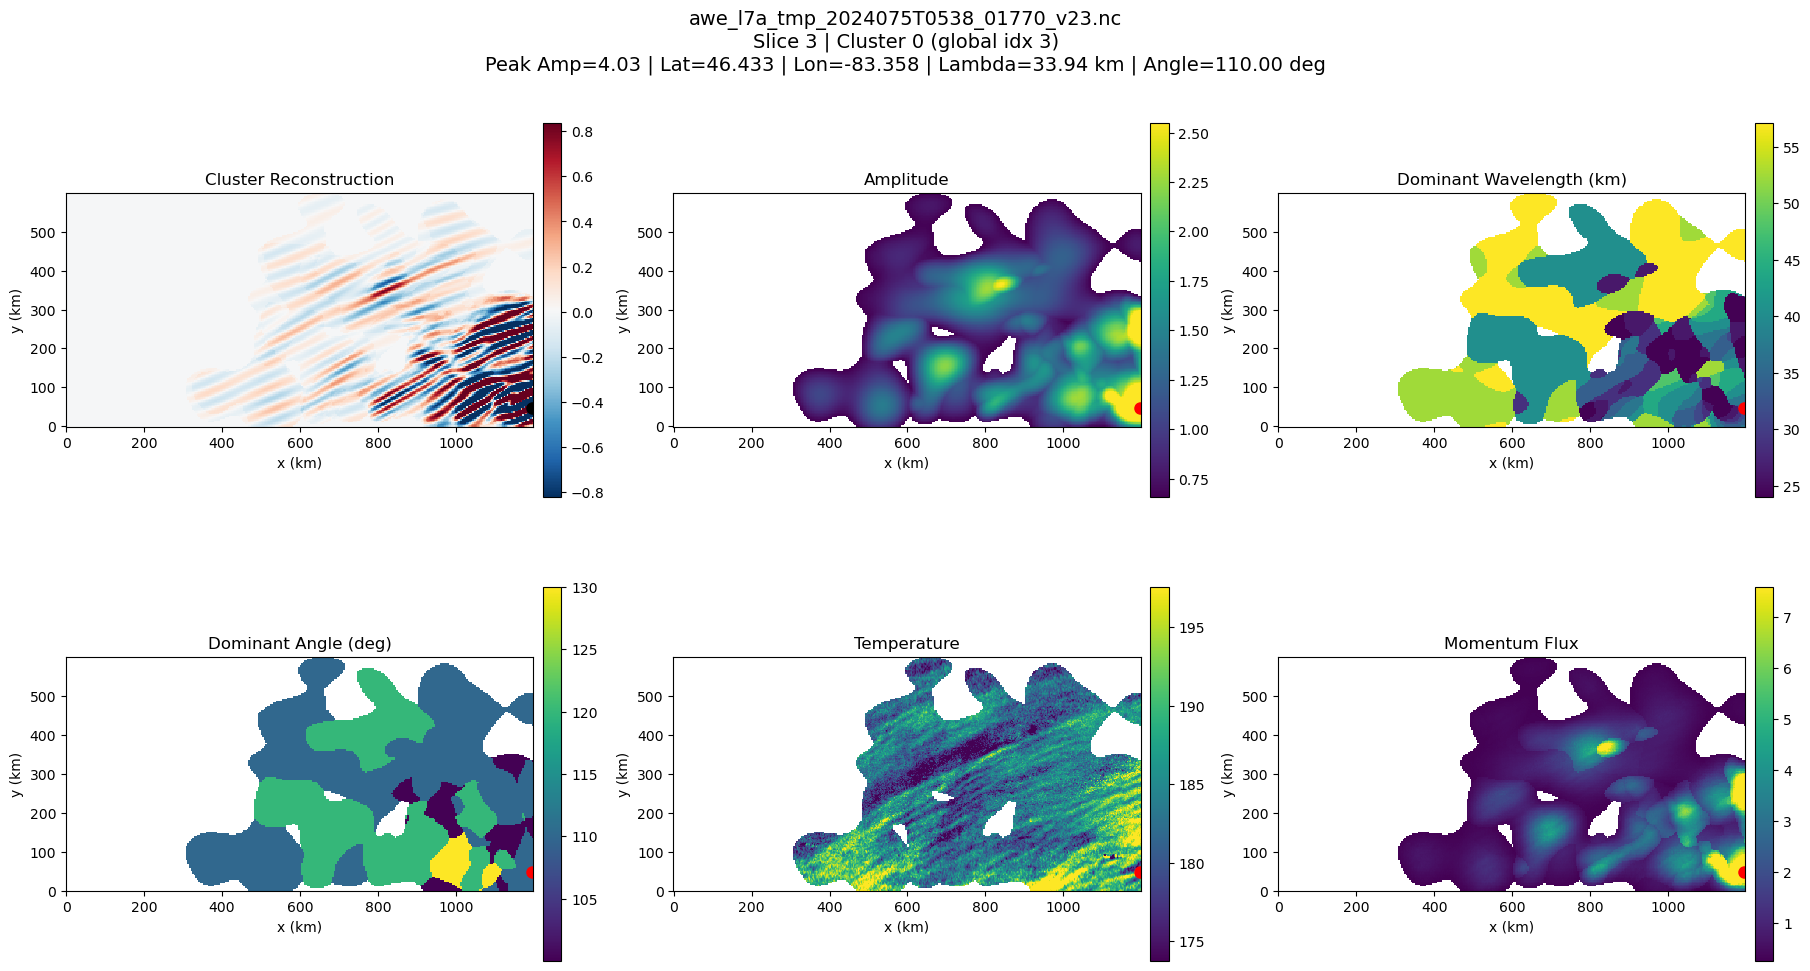

In [3]:
# %%
"""
Plot one cluster from an L7A file and display all information
for the peak-amplitude point.

Change:
    NC_PATH
    TARGET_SLICE
    TARGET_CLUSTER_IN_SLICE

TARGET_CLUSTER_IN_SLICE means:
    0 = first cluster in that slice
    1 = second cluster in that slice
    etc.

This is NOT the global cluster index.
"""

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset


# ============================================================
# Settings
# ============================================================
NC_PATH = Path(
    "l7/2024/03_v23/awe_l7a_tmp_2024075T0538_01770_v23.nc"
)

TARGET_SLICE = 3
TARGET_CLUSTER_IN_SLICE = 0

DX_KM = 2.0
DY_KM = 2.0

DPI = 200


# ============================================================
# Helpers
# ============================================================
def robust_limits(a, p_lo=2, p_hi=98):
    a = np.asarray(a, dtype=float)

    good = np.isfinite(a)

    if not np.any(good):
        return -1.0, 1.0

    lo, hi = np.nanpercentile(a[good], [p_lo, p_hi])

    if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (lo == hi):
        lo = np.nanmin(a[good])
        hi = np.nanmax(a[good])

    return float(lo), float(hi)


# ============================================================
# Read data
# ============================================================
with Dataset(NC_PATH, "r") as nc:

    slices_all = np.asarray(nc.variables["SlicesNo"][:], dtype=int)

    idx_in_slice = np.where(slices_all == TARGET_SLICE)[0]

    if idx_in_slice.size == 0:
        raise ValueError(f"No clusters found for slice {TARGET_SLICE}")

    if TARGET_CLUSTER_IN_SLICE >= idx_in_slice.size:
        raise ValueError(
            f"TARGET_CLUSTER_IN_SLICE={TARGET_CLUSTER_IN_SLICE} "
            f"but only {idx_in_slice.size} clusters exist in slice {TARGET_SLICE}"
        )

    cluster_idx = int(idx_in_slice[TARGET_CLUSTER_IN_SLICE])

    print("=" * 70)
    print(f"Slice                : {TARGET_SLICE}")
    print(f"Cluster in slice     : {TARGET_CLUSTER_IN_SLICE}")
    print(f"Global cluster index : {cluster_idx}")
    print("=" * 70)

    # --------------------------------------------------------
    # Read variables
    # --------------------------------------------------------
    A = np.asarray(
        nc.variables["Amplitude"][cluster_idx],
        dtype=float,
    )

    L = np.asarray(
        nc.variables["DominantWavelength"][cluster_idx],
        dtype=float,
    )

    T_rad = np.asarray(
        nc.variables["Angle"][cluster_idx],
        dtype=float,
    )

    T_deg = np.rad2deg(T_rad) % 180.0

    R = np.asarray(
        nc.variables["ClusterReconstruction"][cluster_idx],
        dtype=float,
    )

    # Optional variables
    temp_exists = "Temp_cluster" in nc.variables
    mf_exists = "MF_cluster" in nc.variables

    if temp_exists:
        Temp = np.asarray(
            nc.variables["Temp_cluster"][cluster_idx],
            dtype=float,
        )

    if mf_exists:
        MF = np.asarray(
            nc.variables["MF_cluster"][cluster_idx],
            dtype=float,
        )

    # --------------------------------------------------------
    # Peak amplitude point
    # --------------------------------------------------------
    if not np.any(np.isfinite(A)):
        raise ValueError("Cluster contains no finite amplitude pixels.")

    yy, xx = np.unravel_index(np.nanargmax(A), A.shape)

    peak_amp = A[yy, xx]
    peak_lambda = L[yy, xx]
    peak_angle_deg = T_deg[yy, xx]

    # Read saved peak lat/lon if available
    lat = np.nan
    lon = np.nan

    if "PeakAmplitude_Latitude" in nc.variables:
        lat = float(
            nc.variables["PeakAmplitude_Latitude"][cluster_idx]
        )

    if "PeakAmplitude_Longitude" in nc.variables:
        lon = float(
            nc.variables["PeakAmplitude_Longitude"][cluster_idx]
        )

    # --------------------------------------------------------
    # Print info
    # --------------------------------------------------------
    print(f"Peak y index         : {yy}")
    print(f"Peak x index         : {xx}")
    print(f"Peak amplitude       : {peak_amp:.3f}")
    print(f"Peak wavelength (km) : {peak_lambda:.3f}")
    print(f"Peak angle (deg)     : {peak_angle_deg:.3f}")
    print(f"Peak latitude        : {lat:.5f}")
    print(f"Peak longitude       : {lon:.5f}")

    n_pix = int(np.count_nonzero(np.isfinite(A)))

    print(f"Finite pixels        : {n_pix}")

# ============================================================
# Coordinates
# ============================================================
ny, nx = A.shape

x1d_km = np.arange(nx) * DX_KM
y1d_km = np.arange(ny) * DY_KM


# ============================================================
# Plot
# ============================================================
nrows = 2
ncols = 3

fig, axs = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 10),
    constrained_layout=True,
)

axs = axs.ravel()

# ------------------------------------------------------------
# Reconstruction
# ------------------------------------------------------------
vmin, vmax = robust_limits(R)

im = axs[0].pcolormesh(
    x1d_km,
    y1d_km,
    R,
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    cmap="RdBu_r",
)

axs[0].plot(
    xx * DX_KM,
    yy * DY_KM,
    "ko",
    markersize=8,
)

axs[0].set_title("Cluster Reconstruction")
axs[0].set_xlabel("x (km)")
axs[0].set_ylabel("y (km)")
axs[0].set_aspect("equal")

fig.colorbar(im, ax=axs[0], fraction=0.04, pad=0.02)

# ------------------------------------------------------------
# Amplitude
# ------------------------------------------------------------
vmin, vmax = robust_limits(A)

im = axs[1].pcolormesh(
    x1d_km,
    y1d_km,
    A,
    shading="auto",
    vmin=vmin,
    vmax=vmax,
)

axs[1].plot(
    xx * DX_KM,
    yy * DY_KM,
    "ro",
    markersize=8,
)

axs[1].set_title("Amplitude")
axs[1].set_xlabel("x (km)")
axs[1].set_ylabel("y (km)")
axs[1].set_aspect("equal")

fig.colorbar(im, ax=axs[1], fraction=0.04, pad=0.02)

# ------------------------------------------------------------
# Wavelength
# ------------------------------------------------------------
vmin, vmax = robust_limits(L)

im = axs[2].pcolormesh(
    x1d_km,
    y1d_km,
    L,
    shading="auto",
    vmin=vmin,
    vmax=vmax,
)

axs[2].plot(
    xx * DX_KM,
    yy * DY_KM,
    "ro",
    markersize=8,
)

axs[2].set_title("Dominant Wavelength (km)")
axs[2].set_xlabel("x (km)")
axs[2].set_ylabel("y (km)")
axs[2].set_aspect("equal")

fig.colorbar(im, ax=axs[2], fraction=0.04, pad=0.02)

# ------------------------------------------------------------
# Angle
# ------------------------------------------------------------
vmin, vmax = robust_limits(T_deg)

im = axs[3].pcolormesh(
    x1d_km,
    y1d_km,
    T_deg,
    shading="auto",
    vmin=vmin,
    vmax=vmax,
)

axs[3].plot(
    xx * DX_KM,
    yy * DY_KM,
    "ro",
    markersize=8,
)

axs[3].set_title("Dominant Angle (deg)")
axs[3].set_xlabel("x (km)")
axs[3].set_ylabel("y (km)")
axs[3].set_aspect("equal")

fig.colorbar(im, ax=axs[3], fraction=0.04, pad=0.02)

# ------------------------------------------------------------
# Temperature
# ------------------------------------------------------------
if temp_exists:

    vmin, vmax = robust_limits(Temp)

    im = axs[4].pcolormesh(
        x1d_km,
        y1d_km,
        Temp,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )

    axs[4].plot(
        xx * DX_KM,
        yy * DY_KM,
        "ro",
        markersize=8,
    )

    axs[4].set_title("Temperature")
    axs[4].set_xlabel("x (km)")
    axs[4].set_ylabel("y (km)")
    axs[4].set_aspect("equal")

    fig.colorbar(im, ax=axs[4], fraction=0.04, pad=0.02)

else:
    axs[4].axis("off")

# ------------------------------------------------------------
# Momentum Flux
# ------------------------------------------------------------
if mf_exists:

    vmin, vmax = robust_limits(MF)

    im = axs[5].pcolormesh(
        x1d_km,
        y1d_km,
        MF,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )

    axs[5].plot(
        xx * DX_KM,
        yy * DY_KM,
        "ro",
        markersize=8,
    )

    axs[5].set_title("Momentum Flux")
    axs[5].set_xlabel("x (km)")
    axs[5].set_ylabel("y (km)")
    axs[5].set_aspect("equal")

    fig.colorbar(im, ax=axs[5], fraction=0.04, pad=0.02)

else:
    axs[5].axis("off")

# ============================================================
# Main title
# ============================================================
fig.suptitle(
    (
        f"{NC_PATH.name}\n"
        f"Slice {TARGET_SLICE} | "
        f"Cluster {TARGET_CLUSTER_IN_SLICE} "
        f"(global idx {cluster_idx})\n"
        f"Peak Amp={peak_amp:.2f} | "
        f"Lat={lat:.3f} | "
        f"Lon={lon:.3f} | "
        f"Lambda={peak_lambda:.2f} km | "
        f"Angle={peak_angle_deg:.2f} deg"
    ),
    fontsize=14,
)

plt.show()